# Canonical SBD simulation and estimation

This notebook implements simulation and estimation using the SBD model and Metropolis-within-Gibbs sampler with Gibbs and HMC blur updates from the paper "Bayesian Semi-Blind Deconvolution at Scale" from Senn et al. (2026). 

Use this notebook to:

1. Simulate a dataset from the SBD model
$$\bm{d}_o = \bm{\omega} \star \bm{c} + \bm{e}$$
using the probabilistic model 
$$\bm{c} \sim N(0, \sigma_c^2 \bm{R}_c), \quad \bm{w} \sim N(0, \sigma_w^2 \bm{R}_w), \quad \bm{e} \sim N(0, \sigma_d^2 \bm{R}_d)$$
subject to constraints 
$$\bm{A}_w \bm{w} = 0, \quad \bm{A}_c \bm{c} = \bm{c}_o \quad \text{and} \quad \bm{A}_d \bm{d} = \bm{d}_o,$$
with marginal variance hyperparameters
$$\sigma_d^2 \propto \sigma_c^2 \sigma_w^2 \zeta, \quad \zeta \sim IG(\alpha_{\zeta}, \beta_{\zeta}), \quad \sigma_c^2 \sim IG(\alpha_{c}, \beta_{c}), \quad \sigma_w^2 \sim IG(\alpha_{w}, \beta_{w}).$$

2. Run Metropolis-within-Gibbs to recover the $\bm{d}_u$, $\bm{\omega}$, $\bm{c}_u$, $\sigma_c^2$, $\sigma_w^2$, and $\zeta$ parameters from the original dataset. The blur update can be done with Gibbs from its full conditional, or with HMC. 

3. Save simulated data, estimations, figures, and tables.

Contact guillermina.senn@ntnu.no for questions.

## How to run this notebook (no package install)

This repo is set up so you can run the notebook directly after installing dependencies.

1. Install dependencies (from the repo root):
   - `python -m venv .venv`
   - `source .venv/bin/activate`
   - `pip install -r requirements.txt`

2. Open this notebook and run cells top-to-bottom.

Outputs (data/models/figures/tables) are written under `data/`, `estimations/`, and `reports/` inside the repo root (paths are printed below).

**Tip:** If you get an `ImportError`, it usually means the notebook couldn’t locate the repo root. The next cell auto-detects the repo root by searching upwards for `pyproject.toml` + `src/`.

In [5]:
# ----------------------------------
# 0. Imports and paths
# ----------------------------------

import os
import sys
import time
import random
import pickle
import copy

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure the repo root is on sys.path so local `src/` imports work even if
# the notebook is launched from a different working directory.
def _find_repo_root(start_dir: Path) -> Path:
    candidates = [start_dir] + list(start_dir.parents)
    for p in candidates:
        if (p / "pyproject.toml").exists() and (p / "src").exists():
            return p
    for p in candidates:
        if (p / "setup.cfg").exists() and (p / "src").exists():
            return p
    # Fallback: assume we are in `notebooks/` and the repo root is one level up.
    return start_dir.parent

root_path = _find_repo_root(Path.cwd().resolve())
root_dir = str(root_path)

# Pin repo root to the front to avoid importing an installed copy by accident.
if root_dir in sys.path:
    sys.path.remove(root_dir)
sys.path.insert(0, root_dir)
print("Using repo root:", root_dir)

from src.classes.lattice import Lattice
from src.classes.model import ConvolutionalModel
from src.mcmc.mcmc import MCMC
from src.utils.file_utils import read_sampler_object, read_stats, read_samples

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.figsize'] = [4, 3]
plt.rcParams['figure.dpi'] = 150

Using repo root: /Users/guillers/Documents/GitHub/bsbd


## Model Configuration

Choose the effective blur length $k$, the number of rows $n_v^{\mathrm{obs}}$ and columns $n_h^{\mathrm{obs}}$ in the observed lattice, and the vertical and horizontal margins $m_v$ and $m_h$ for the extended cyclic lattice (`topology`='C'). Then, choose the column and rows where the exact image observations are located.

In [ ]:
# For reproducibility
seed = 20
random.seed(seed)
np.random.seed(seed)

# Lattice and data settings
# `obs` = observed lattice size (user-facing terminology).
eff_blur_length = 6
nv_obs = 12
nh_obs = 2

# Compatibility aliases (the `src` API uses *_ava naming)
nv_ava = nv_obs
nh_ava = nh_obs

mv = 0
mh = 0
topology = 'C'

# Exact image observation constraints ("well")
# None -> full well column; 0 -> no constraints; >0 -> that many rows
n_well_observations = None
well_column_obs = None  # None -> center column of observed lattice

# Compatibility alias for `src` functions expecting `well_column_ava`
well_column_ava = well_column_obs


Choose values for the hyperparameters in the variance, image, and blur priors:

In [ ]:
# Priors
alpha_w = 2.01
beta_w = 10
alpha_c = 2.00001
beta_c = 1 / 500
alpha_zeta = 3
beta_zeta = 0.1
zeta_init = 0.05  # SNR_init = 1/zeta_init

# Correlation settings
rho_w = 1.5  # correlation range for the blur
rho_v = 1.5  # vertical correlation range for the image and observed data
rho_h = 1.5  # horizontal correlation range for the image and observed data


Set up the sampler. For HMC:
* Use the dictionary `adapt_config` to adapt the step-size `epsilon` and number of leapfrog steps `L` on the fly.
* Use `p_collapsed_hmc`=1 to run HMC, and `p_collapsed_hmc`<1 to run HMC with probability  `p_collapsed_hmc` and Gibbs with probability 1-`p_collapsed_hmc`.
* Set `precondition`='prior' to use the prior inverse covariance matrix as momentum mass matrix. This overrides the momentum variance `sigma2p`. If `precondition`=None, `sigma2p` is used and fixed across iterations.


In [8]:
# MCMC settings
chunk_size = 1000 # estimations will be saved to disk in files of this many samples
N_gibbs = 1000 # number of Gibbs iterations
N_hmc = 1000 # number of HMC iterations 
burnin = 500 # used for both gibbs and HMC
thinning = 1 # for plotting and stats

# Gibbs settings
gibbs_config = {
    'verbose': False,
    'save_stats': True,
}

# HMC settings
adapt_config = { 
    'collapsed_hmc': {
        'epsilon': {
            'type': 'rosenthal',
            'B': 30,
            'min': 0.00001,
            'max': 0.03,
            'optimal_ar': 0.4,
            'max_change': 0.001,
            'min_beta': 0.00001,
            'max_beta': 0.02,
            'verbose': False
        },
        'L': {
            'type': 'random',
            'min': 20,
            'max': 20
        }
    },
}

hmc_config = {
    'epsilon': 0.008,
    'L': 20,
    'sigma2p': 1, # momentum variance
    'precondition': 'prior',
    'adapt_config': adapt_config,
    'verbose': False,
    'save_stats': True,
    'p_collapsed_hmc': 1, # probability of using collapsed HMC; else, will do 
}

Configuration for saving the samples:

In [ ]:

# Folder identifier for outputs
folder_id = f"k{eff_blur_length}_nv{nv_obs}_nh{nh_obs}_mv{mv}_mh{mh}_seed{seed}"

# Output roots
data_dir = os.path.join(root_dir, 'data', 'processed', folder_id)
estim_root = os.path.join(root_dir, 'estimations', folder_id)
reports_root = os.path.join(root_dir, 'reports', folder_id)
figures_dir = os.path.join(reports_root, 'figures')
tables_dir = os.path.join(reports_root, 'tables')

for d in [data_dir, estim_root, figures_dir, tables_dir]:
    os.makedirs(d, exist_ok=True)

print('folder_id =', folder_id)
print('data_dir =', data_dir)
print('estim_root =', estim_root)
print('figures_dir =', figures_dir)
print('tables_dir =', tables_dir)


folder_id = k6_nv12_nh2_mv0_mh0_seed20
data_dir = /Users/guillers/Documents/GitHub/bsbd/data/processed/k6_nv12_nh2_mv0_mh0_seed20
estim_root = /Users/guillers/Documents/GitHub/bsbd/estimations/k6_nv12_nh2_mv0_mh0_seed20
figures_dir = /Users/guillers/Documents/GitHub/bsbd/reports/k6_nv12_nh2_mv0_mh0_seed20/figures
tables_dir = /Users/guillers/Documents/GitHub/bsbd/reports/k6_nv12_nh2_mv0_mh0_seed20/tables


## Helper functions for simulating data, running MCMC, and displaying results

For simulating data:

In [ ]:
def build_model(lattice, observed_b=None, image_b=None, verbose=False):
    model = ConvolutionalModel(lattice)

    # Variances (blur/image)
    model.setup_wavelet_variance(alpha=alpha_w, beta=beta_w)
    model.initialize_wavelet_variance(init=None)
    model.setup_reflectivity_variance(alpha=alpha_c, beta=beta_c)
    model.initialize_reflectivity_variance(init=None)
    model.setup_inverse_snr(alpha=alpha_zeta, beta=beta_zeta)
    model.initialize_inverse_snr(init=zeta_init)

    # Blur and image priors
    model.setup_wavelet_prior(rho=rho_w, constr=True, verbose=verbose)
    model.initialize_wavelet(verbose=verbose)
    model.setup_reflectivity_prior(rho_v=rho_v, rho_h=rho_h, b=image_b, verbose=verbose)
    model.initialize_reflectivity(verbose=verbose)

    # Observation (data) model
    model.setup_seismic_model(rho_v=rho_v, rho_h=rho_h, b=observed_b, verbose=verbose)
    model.initialize_seismic(verbose=verbose)

    return model


def get_image_well_subset(model, well_column_obs=None, n_obs=None):
    """Return (image_b, rows_obs) for exact-image observation constraints.

    n_obs semantics:
    - None: constrain the full observed column (nv_obs rows)
    - 0: no constraints (returns b=None, rows_obs=[])
    - >0: constrain exactly n_obs rows (deterministic contiguous block centered around nv_obs//2)

    Notes:
    - The underlying `src` API uses *_ava naming internally; this function keeps those calls unchanged.
    """

    lattice = model.lattice
    nv_obs_local = lattice.nv_ava

    if n_obs == 0:
        return None, np.array([], dtype=int)

    if n_obs is None:
        rows_obs = np.arange(nv_obs_local, dtype=int)
    else:
        if n_obs < 0:
            raise ValueError(f"n_obs must be None, 0, or >0 (got {n_obs})")
        n_obs = int(n_obs)
        if n_obs > nv_obs_local:
            raise ValueError(f"n_obs={n_obs} exceeds nv_obs={nv_obs_local}")

        # Choose a centered *contiguous* block of rows.
        # Example: nv_obs=12 -> mid=6; n_obs=4 -> [4, 5, 6, 7]
        mid = nv_obs_local // 2
        start = mid - (n_obs // 2)
        end = start + n_obs  # exclusive
        if start < 0:
            start = 0
            end = n_obs
        if end > nv_obs_local:
            end = nv_obs_local
            start = nv_obs_local - n_obs
        rows_obs = np.arange(start, end, dtype=int)

    lattice.create_obs_reflectivity_positions(
        well_column_ava=well_column_obs,
        rows_ava=rows_obs,
        verbose=False,
    )
    well_coords_vec = lattice.well_positions['well_coords_vec']

    image_vec = model.theta['c_star'].reshape(-1)
    image_b = image_vec[well_coords_vec].reshape(-1, 1)
    return image_b, rows_obs


For running MCMC. You will need to pass a `ConvolutionalModel` object that contains the true data, another that contains the initial data, and another that contains the model configurataion. 

In [16]:

def run_sampler(data_model, init_model, algorithm, N, config=None, theta_init=None):
    estimate = ['c_star', 'w_star', 'sigma2c', 'sigma2w', 'zeta']
    if data_model.lattice.n > data_model.lattice.n_ava:
        estimate.append('d_star')

    theta0 = init_model.theta if theta_init is None else theta_init

    sampler = MCMC(
        model=data_model,
        theta_init=theta0,
        estimate=estimate,
        theta_true=data_model.theta,
        chunk_size=chunk_size,
        path=estim_root + '/',
    )

    run_kwargs = {} if config is None else dict(config)
    print(f"run_kwargs:\n{run_kwargs}")
    return sampler.run(N, algorithm, **run_kwargs)

def load_results(filenames, thinning=1):
    path, folder, model_filename = filenames
    sampler = read_sampler_object(path, folder, model_filename)
    stats = read_stats(path, folder, model_filename)
    chunk_size_local = sampler['file_config']['chunk_size']
    estimations, _ = read_samples(path, folder, model_filename, chunk_size=chunk_size_local, thinning=thinning)
    return sampler, stats, estimations

Plotting:

In [14]:

def posterior_summary(samples, burnin_idx=0, q=(0.05, 0.95)):
    if samples.shape[1] <= burnin_idx:
        used = samples
    else:
        used = samples[:, burnin_idx:]
    mean = np.mean(used, axis=1)
    lower = np.quantile(used, q[0], axis=1)
    upper = np.quantile(used, q[1], axis=1)
    std = np.std(used, axis=1)
    return mean, lower, upper, std

def plot_trace(samples, title, ax, true_val=None, mean_val=None):
    ax.plot(samples.T, linewidth=0.4)
    if mean_val is not None:
        ax.axhline(float(np.squeeze(mean_val)), color='C1', linewidth=1.5, label='mean')
    if true_val is not None:
        ax.axhline(float(np.squeeze(true_val)), color='C0', linewidth=1.5, linestyle='--', label='true')
    if (mean_val is not None) or (true_val is not None):
        ax.legend(fontsize=8)
    ax.set_title(title)
    ax.set_xlabel('Iteration')
    ax.grid(True, linestyle=':')

def plot_trace_subset(samples, title, ax, n_traces=5, central_k=None):
    n = samples.shape[0]
    n_traces = min(n_traces, n)
    if n_traces <= 0:
        return

    if central_k is not None and 0 < central_k < n:
        start = (n - central_k) // 2
        end = start + central_k
        valid_idx = np.arange(start, end, dtype=int)
    else:
        valid_idx = np.arange(n, dtype=int)

    n_traces = min(n_traces, len(valid_idx))
    if n_traces <= 0:
        return

    pick = np.linspace(0, len(valid_idx) - 1, n_traces, dtype=int)
    idx = valid_idx[pick]
    ax.plot(samples[idx, :].T, linewidth=0.6, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Iteration')
    ax.grid(True, linestyle=':')

def plot_vector_posterior_draws(true_vec, samples, burnin_idx=0, n_draws=50, title='', ax=None):
    if ax is None:
        ax = plt.gca()
    used = samples[:, burnin_idx:] if samples.shape[1] > burnin_idx else samples
    n_samples = used.shape[1]
    draw_idx = np.random.choice(n_samples, size=min(n_draws, n_samples), replace=False)
    x = np.arange(used.shape[0])
    for j in draw_idx:
        ax.plot(x, used[:, j], color='C1', alpha=0.08, linewidth=0.6)
    mean_vec = np.mean(used, axis=1)
    ax.plot(x, mean_vec, color='C1', linewidth=2.0, label='posterior mean')
    ax.plot(true_vec.flatten(), color='C0', linewidth=1.2, label='true')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle=':')

def plot_field_mean(true_vec, mean_vec, lattice, title, ax_true, ax_est):
    true_2d = true_vec.reshape((lattice.nv, lattice.nh), order='F')
    mean_2d = mean_vec.reshape((lattice.nv, lattice.nh), order='F')
    im1 = ax_true.imshow(true_2d, aspect='auto', cmap='viridis')
    im2 = ax_est.imshow(mean_2d, aspect='auto', cmap='viridis')
    ax_true.set_title(f'{title} (true)')
    ax_est.set_title(f'{title} (posterior mean)')
    plt.colorbar(im1, ax=ax_true, fraction=0.046, pad=0.04)
    plt.colorbar(im2, ax=ax_est, fraction=0.046, pad=0.04)

def plot_field_std(std_vec, lattice, title, ax, vmin=None, vmax=None):
    std_2d = std_vec.reshape((lattice.nv, lattice.nh), order='F')
    im = ax.imshow(std_2d, aspect='auto', cmap='magma', vmin=vmin, vmax=vmax)
    ax.set_title(f'{title} (posterior std)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

## Simulate and save one dataset

Covariance class: Explicitly building R and Q because n < 300.
Storing full 1D correlation matrices
Storing R_2d h and/or v
Finished with the spatial correlation matrix.
Storing full 1D correlation matrices
Storing R_2d h and/or v
In math_utils.pseudo_inverse_RH, the largest imaginary component in the eigenvalues was 0.0 < tol=1e-10, so only the real part was kept.
eigvals = [ 1.85925192e+00  6.99380927e-01  1.89060895e-01  4.88123044e-02
  2.70442048e-16 -2.21532734e-16 -1.39950268e-16  9.40861077e-17
 -1.52398227e-17 -1.04290254e-18 -1.04290254e-18  0.00000000e+00]
In math_utils.pseudo_inverse_RH, the number of imaginary log eigenvalues was 0.
log_eigvals = [ 0.62017422 -0.35755973 -1.66568612 -3.01977286  0.          0.
  0.          0.          0.          0.          0.          0.        ]
In math_utils.pseudo_inverse_RH, the number of imaginary pseudo-inverse eigenvalues was 0.
pseudo_inv_eigvals = [ 0.53785073  1.42983596  5.2893011  20.4866378   0.          0.
  0.          0.

/Users/guillers/anaconda3/envs/mess-env/lib/python3.11/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


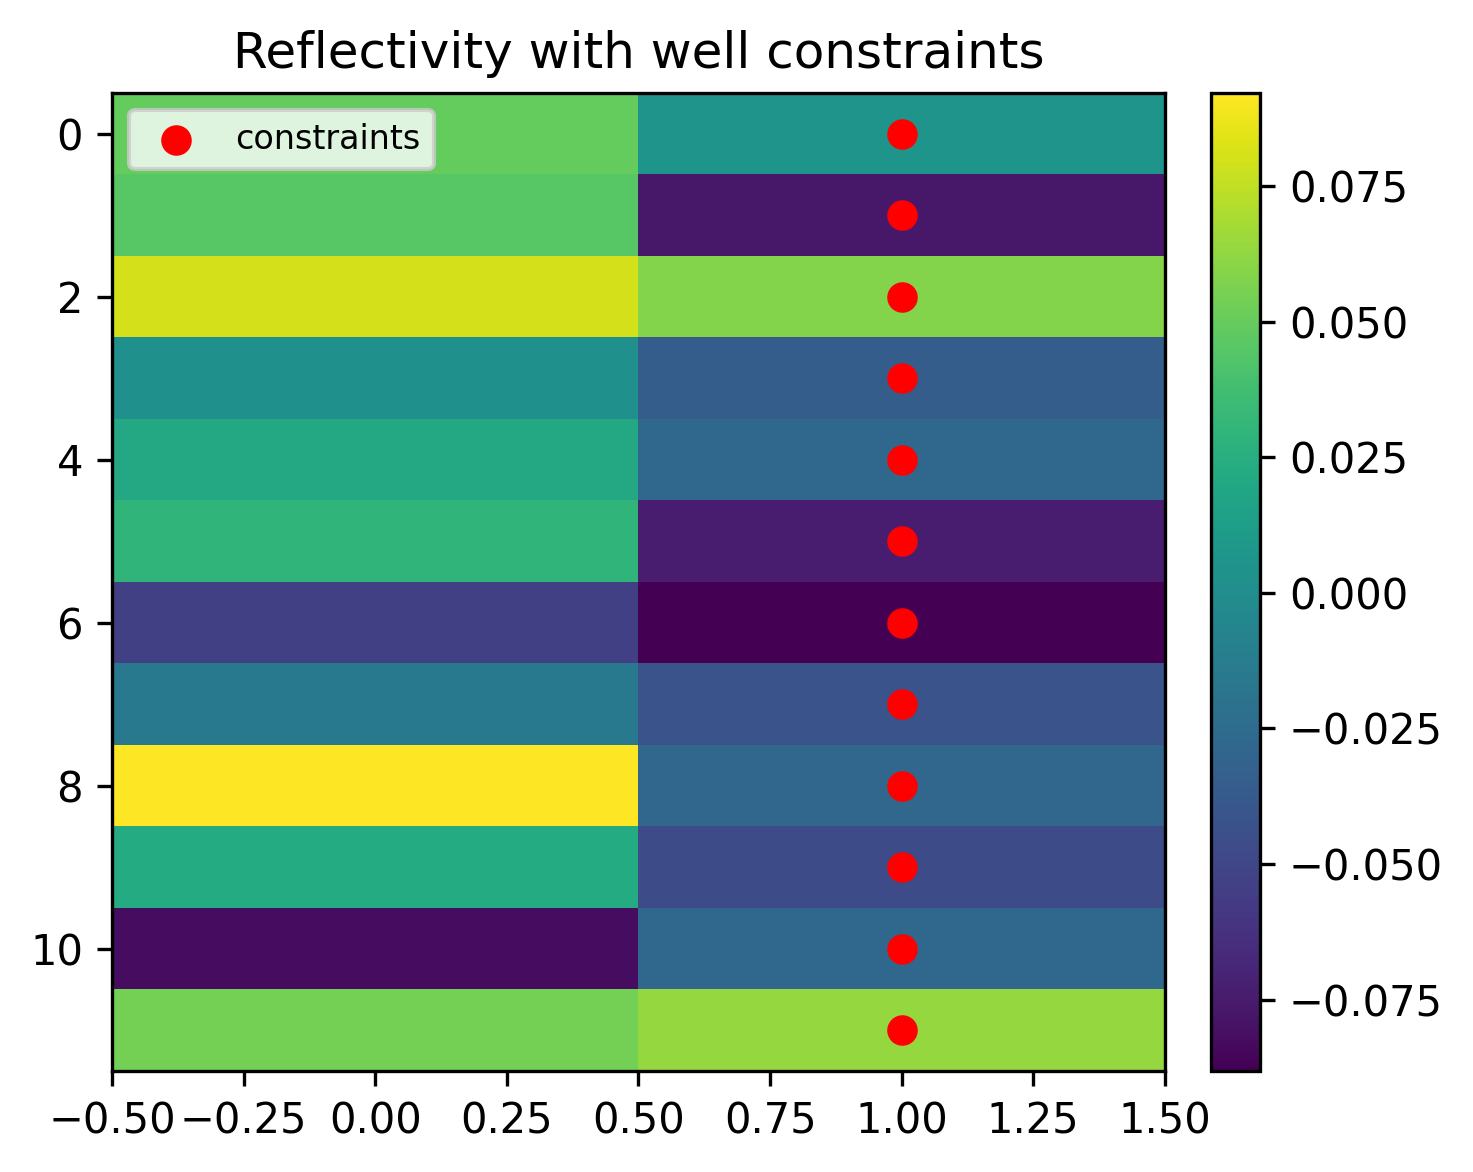

In [ ]:
lattice = Lattice(nv_obs, nh_obs, eff_blur_length, mv=mv, mh=mh, topology=topology)

# Internally, `src` still uses AVA naming for these observed/blur index sets.
lattice.create_ava_positions(verbose=False)
lattice.create_wavelet_positions(verbose=False)

# 1) Simulate full data with unconstrained image
data_true = build_model(lattice, observed_b=None, image_b=None, verbose=False)

folder_data = f"data/processed/{folder_id}/"
data_filename = data_true.save_model(folder=folder_data, path=root_dir + '/')
print('True data saved to:', data_filename)

# ----------------------------------
# 3b. Apply constraints and visualize
# ----------------------------------

image_b, rows_obs = get_image_well_subset(
    data_true,
    well_column_obs=well_column_obs,
    n_obs=n_well_observations,
)
print('Image b:', None if image_b is None else image_b.shape)
print('Constraint rows (obs):', rows_obs)

image_true = data_true.theta['c_star'].reshape((lattice.nv, lattice.nh), order='F')
well_col = lattice.nh_ava // 2 if well_column_obs is None else well_column_obs
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
im = ax.imshow(image_true, aspect='auto', cmap='viridis')
if len(rows_obs) > 0:
    ax.scatter([well_col] * len(rows_obs), rows_obs, color='red', s=40, label='obs')
ax.set_title('Image with exact observation constraints')
ax.legend(fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
constraints_fig = os.path.join(figures_dir, f'{folder_id}_constraints.png')
plt.savefig(constraints_fig, dpi=200)
print('Saved:', constraints_fig)

# ----------------------------------
# 3c. Create constrained data_model and init_model
# ----------------------------------

data_model = copy.deepcopy(data_true)
data_model.setup_reflectivity_prior(rho_v=rho_v, rho_h=rho_h, b=image_b, verbose=False)
data_model.initialize_reflectivity(init=data_true.theta['c_star'], verbose=False)

observed_b = data_true.model['d'].data_constraints['b']
init_model = build_model(
    lattice,
    observed_b=observed_b,
    image_b=image_b,
    verbose=False,
)
init_filename = init_model.save_model(folder=folder_data, path=root_dir + '/')
print('Init model saved to:', init_filename)


## Run MCMC

In [18]:
# ----------------------------------
# 4. Run Gibbs (init = TRUE)
# ----------------------------------

t0 = time.time()
gibbs_filenames = run_sampler(
    data_model,
    init_model,
    algorithm='gibbs',
    N=N_gibbs,
    config=gibbs_config,
    theta_init=data_true.theta,
 )
print('Gibbs finished in', np.round(time.time() - t0, 2), 'seconds')
print('Gibbs files:', gibbs_filenames)

d_star is fixed. Replacing its init value with the true value in theta_true.
run_kwargs:
{'verbose': False, 'save_stats': True}
Will run 1000 iterations of MwG with gibbs for the (w, c) update.
model filename as stored in mcmc obj: C_nv12_nh2_mv0_mh0_k6_snr20.0_d20710c6-19c5-4cbf-ad49-3ed71cc0ba2b
The Sampler dict has been saved to /Users/guillers/Documents/GitHub/bsbd/estimations/k6_nv12_nh2_mv0_mh0_seed20/gibbs/constr_w_constr_c/C_nv12_nh2_mv0_mh0_k6_snr20.0_d20710c6-19c5-4cbf-ad49-3ed71cc0ba2b_gibbs_N1000_runID_2478/C_nv12_nh2_mv0_mh0_k6_snr20.0_d20710c6-19c5-4cbf-ad49-3ed71cc0ba2b_gibbs_N1000_runID_2478.pkl.
Initializing gibbs.
iter=0 and i=0 of chunk_size=1000
iter=1000 and i=0 of chunk_size=1000
Chunk 0 has been saved to /Users/guillers/Documents/GitHub/bsbd/estimations/k6_nv12_nh2_mv0_mh0_seed20/gibbs/constr_w_constr_c/C_nv12_nh2_mv0_mh0_k6_snr20.0_d20710c6-19c5-4cbf-ad49-3ed71cc0ba2b_gibbs_N1000_runID_2478/samples/C_nv12_nh2_mv0_mh0_k6_snr20.0_d20710c6-19c5-4cbf-ad49-3ed71cc0ba

In [19]:
# ----------------------------------
# 5. Run collapsed HMC (init = TRUE)
# ----------------------------------

t0 = time.time()
hmc_filenames = run_sampler(
    data_model,
    init_model,
    algorithm='collapsed_hmc',
    N=N_hmc,
    config=hmc_config,
    theta_init=data_true.theta,
 )
print('Collapsed HMC finished in', np.round(time.time() - t0, 2), 'seconds')
print('Collapsed HMC files:', hmc_filenames)

d_star is fixed. Replacing its init value with the true value in theta_true.
run_kwargs:
{'epsilon': 0.008, 'L': 20, 'sigma2p': 1, 'precondition': 'prior', 'adapt_config': {'collapsed_hmc': {'epsilon': {'type': 'rosenthal', 'B': 30, 'min': 1e-05, 'max': 0.03, 'optimal_ar': 0.4, 'max_change': 0.001, 'min_beta': 1e-05, 'max_beta': 0.02, 'verbose': False}, 'L': {'type': 'random', 'min': 20, 'max': 20}}}, 'verbose': False, 'save_stats': True, 'p_collapsed_hmc': 1}
Will run 1000 iterations of MwG with collapsed_hmc for the (w, c) update.
model filename as stored in mcmc obj: C_nv12_nh2_mv0_mh0_k6_snr20.0_d20710c6-19c5-4cbf-ad49-3ed71cc0ba2b
The Sampler dict has been saved to /Users/guillers/Documents/GitHub/bsbd/estimations/k6_nv12_nh2_mv0_mh0_seed20/collapsed_hmc/constr_w_constr_c/C_nv12_nh2_mv0_mh0_k6_snr20.0_d20710c6-19c5-4cbf-ad49-3ed71cc0ba2b_collapsed_hmc_N1000_runID_4258/C_nv12_nh2_mv0_mh0_k6_snr20.0_d20710c6-19c5-4cbf-ad49-3ed71cc0ba2b_collapsed_hmc_N1000_runID_4258.pkl.
Initializin

## Load results 

Sampler dict has been read from /Users/guillers/Documents/GitHub/bsbd/estimations/k6_nv12_nh2_mv0_mh0_seed20/gibbs/constr_w_constr_c/C_nv12_nh2_mv0_mh0_k6_snr20.0_d20710c6-19c5-4cbf-ad49-3ed71cc0ba2b_gibbs_N1000_runID_2478/C_nv12_nh2_mv0_mh0_k6_snr20.0_d20710c6-19c5-4cbf-ad49-3ed71cc0ba2b_gibbs_N1000_runID_2478.pkl.
Stats dict has been read from /Users/guillers/Documents/GitHub/bsbd/estimations/k6_nv12_nh2_mv0_mh0_seed20/gibbs/constr_w_constr_c/C_nv12_nh2_mv0_mh0_k6_snr20.0_d20710c6-19c5-4cbf-ad49-3ed71cc0ba2b_gibbs_N1000_runID_2478/C_nv12_nh2_mv0_mh0_k6_snr20.0_d20710c6-19c5-4cbf-ad49-3ed71cc0ba2b_gibbs_N1000_runID_2478_stats.pkl.
Chunk size: 1000, Total chunks: 1, thinning: 1, chunk size thinned: 1000, Total samples thinned: 1000
All chunks loaded.
Sampler dict has been read from /Users/guillers/Documents/GitHub/bsbd/estimations/k6_nv12_nh2_mv0_mh0_seed20/collapsed_hmc/constr_w_constr_c/C_nv12_nh2_mv0_mh0_k6_snr20.0_d20710c6-19c5-4cbf-ad49-3ed71cc0ba2b_collapsed_hmc_N1000_runID_4258/

,algorithm,rmse_w,rmse_c,sigma2w_mean,sigma2c_mean,zeta_mean
0,gibbs,0.096888,0.021080,7.622690,0.004005,0.043724
1,collapsed_hmc,0.107836,0.018612,7.202872,0.003787,0.043485


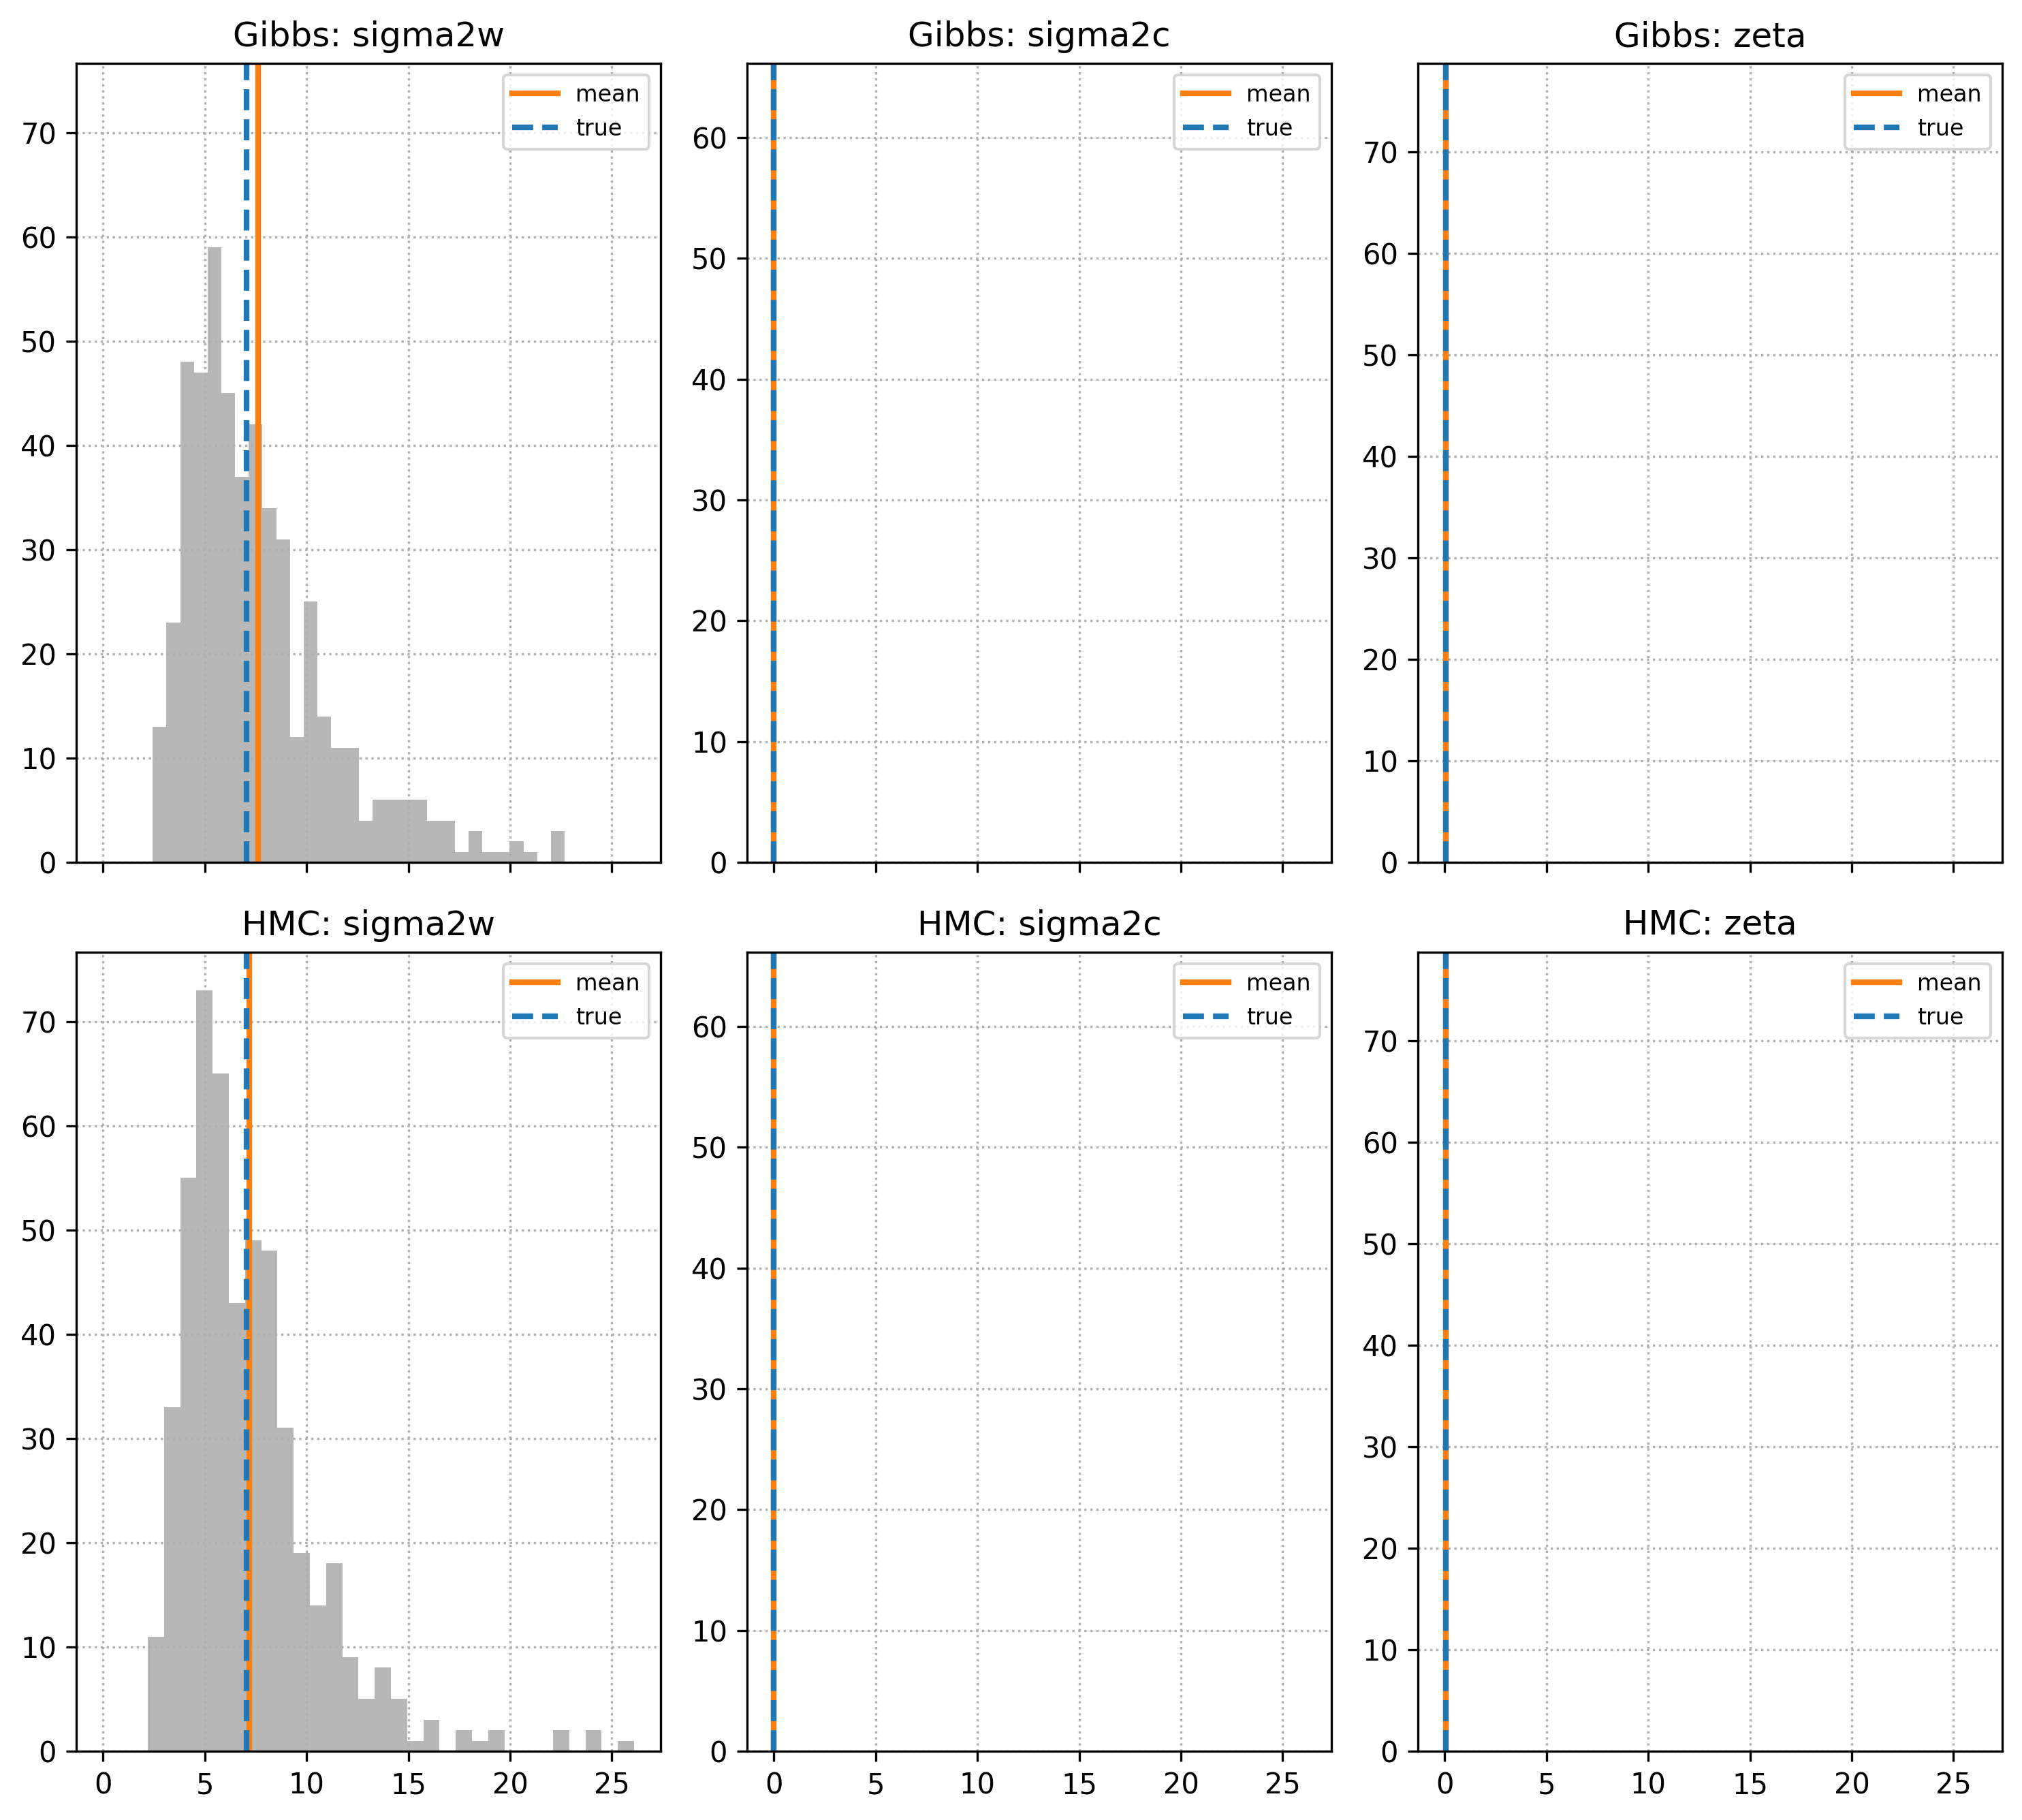

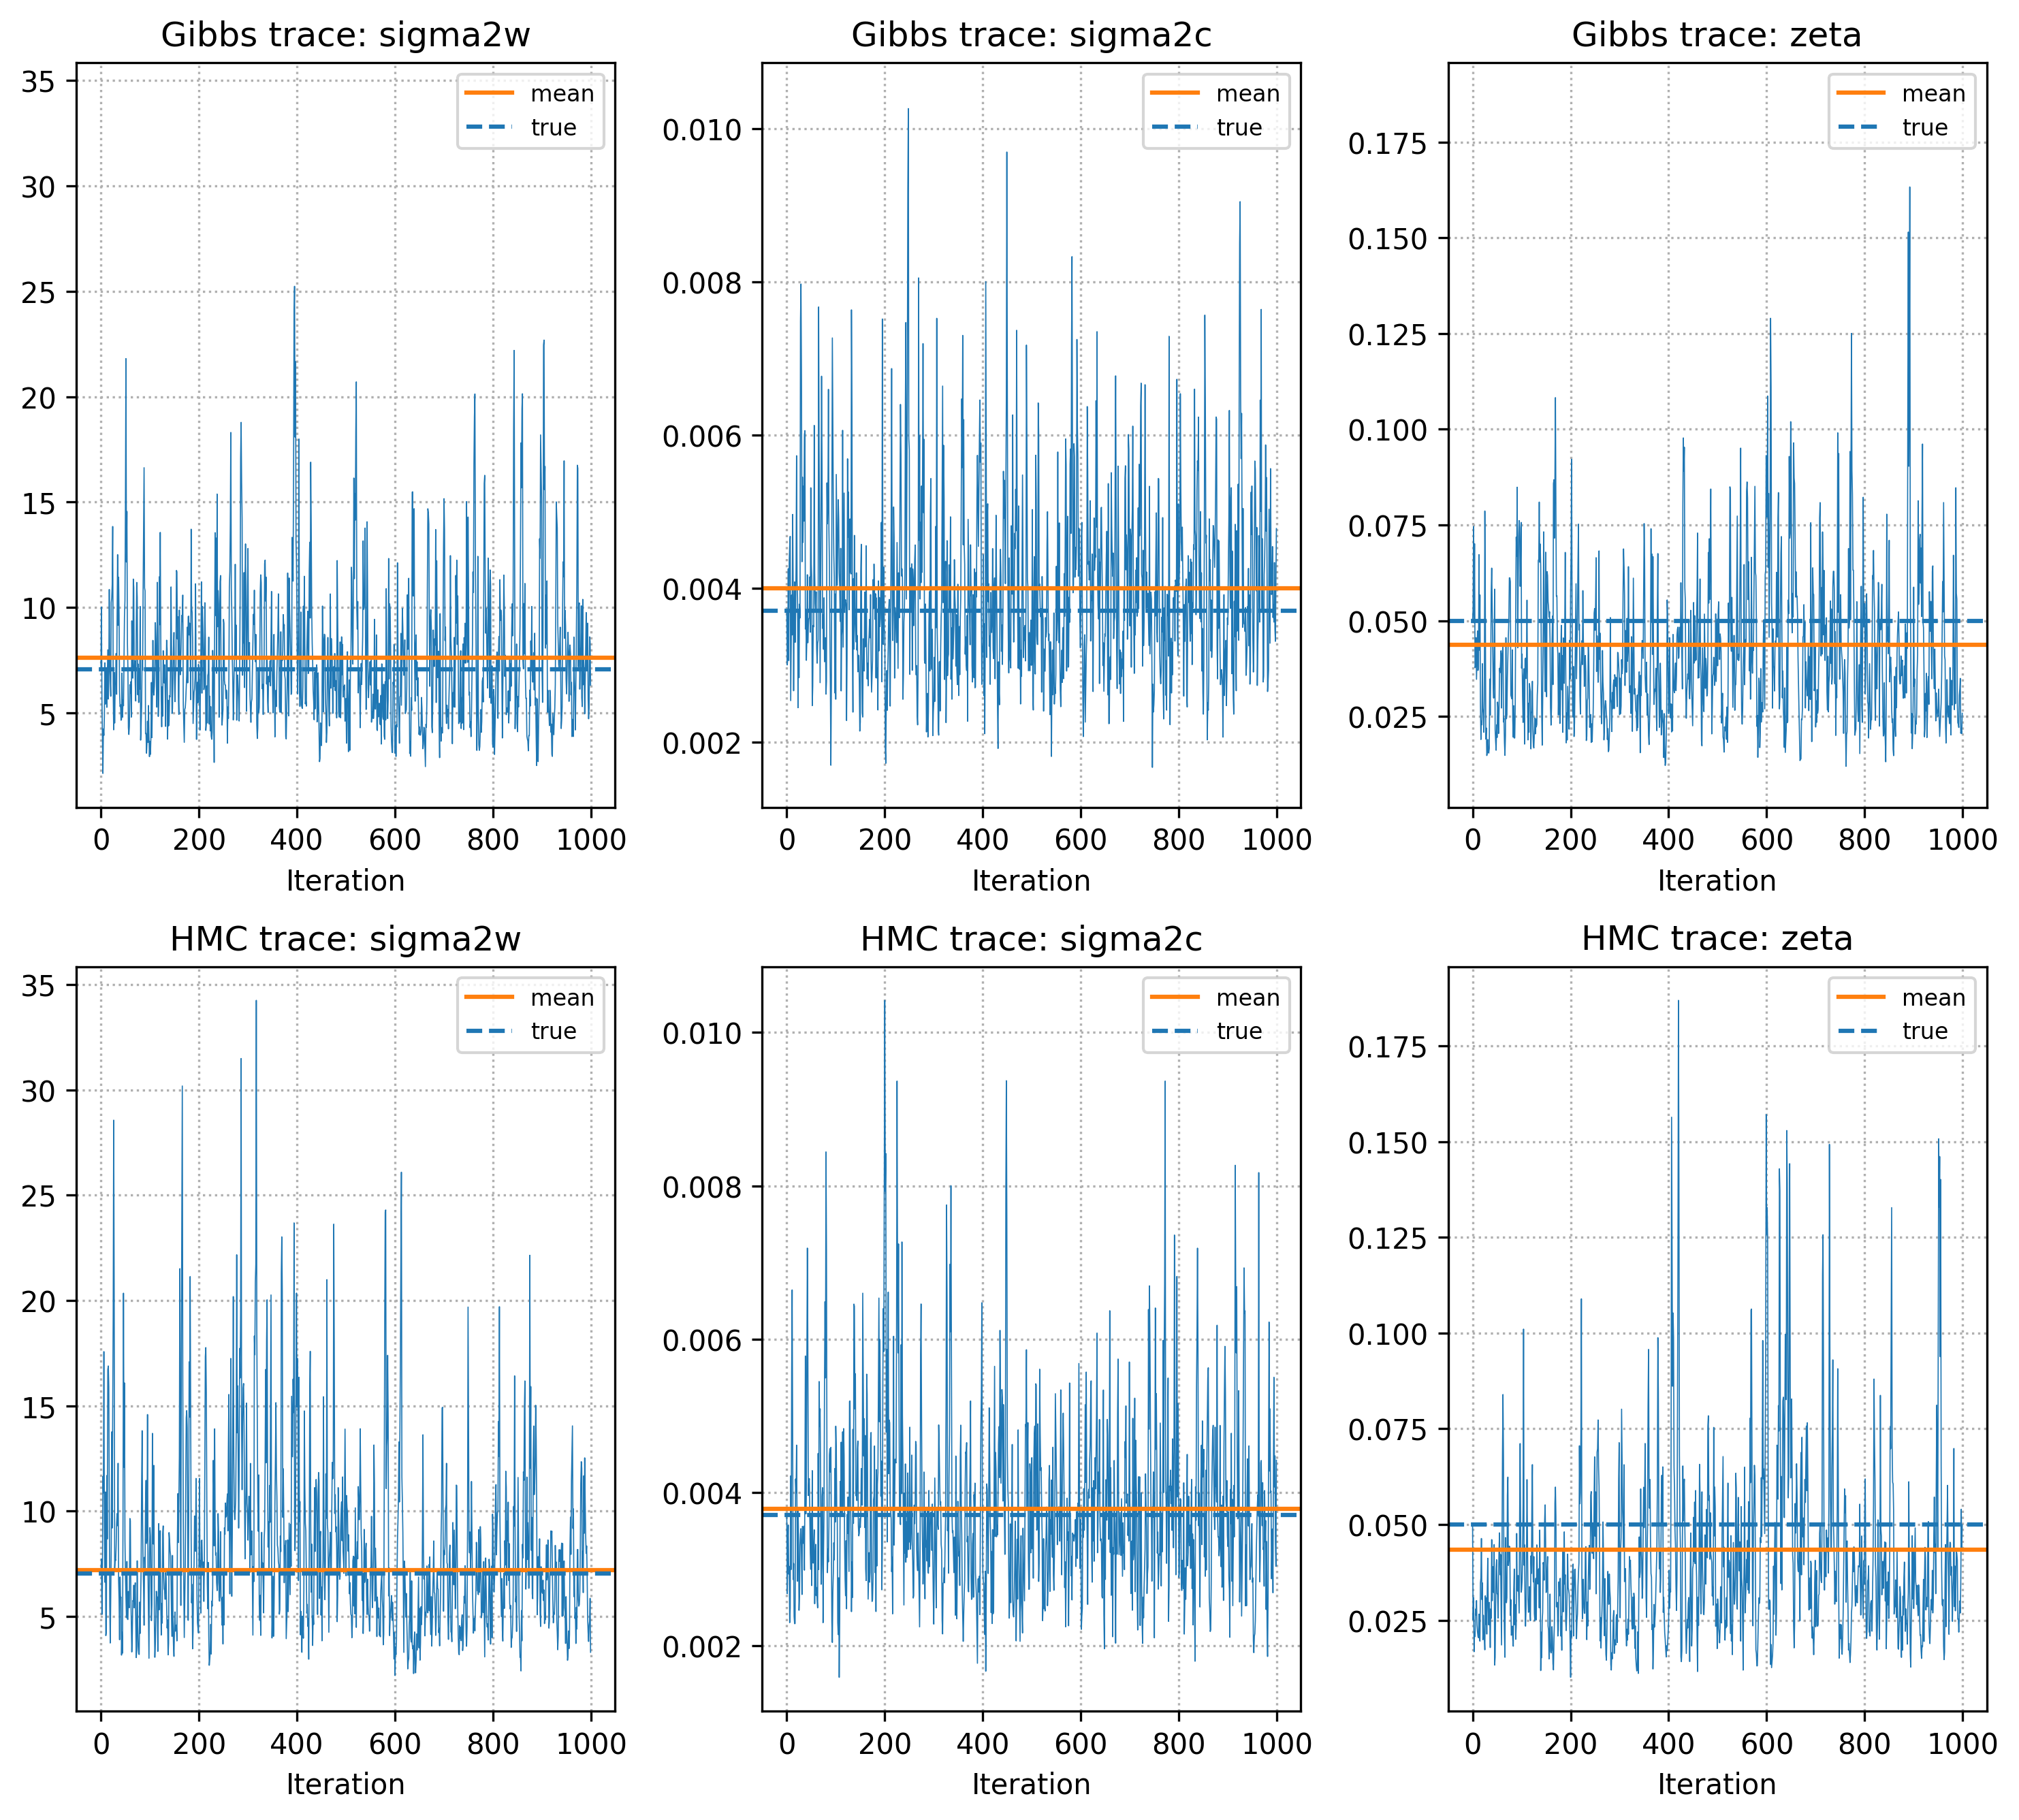

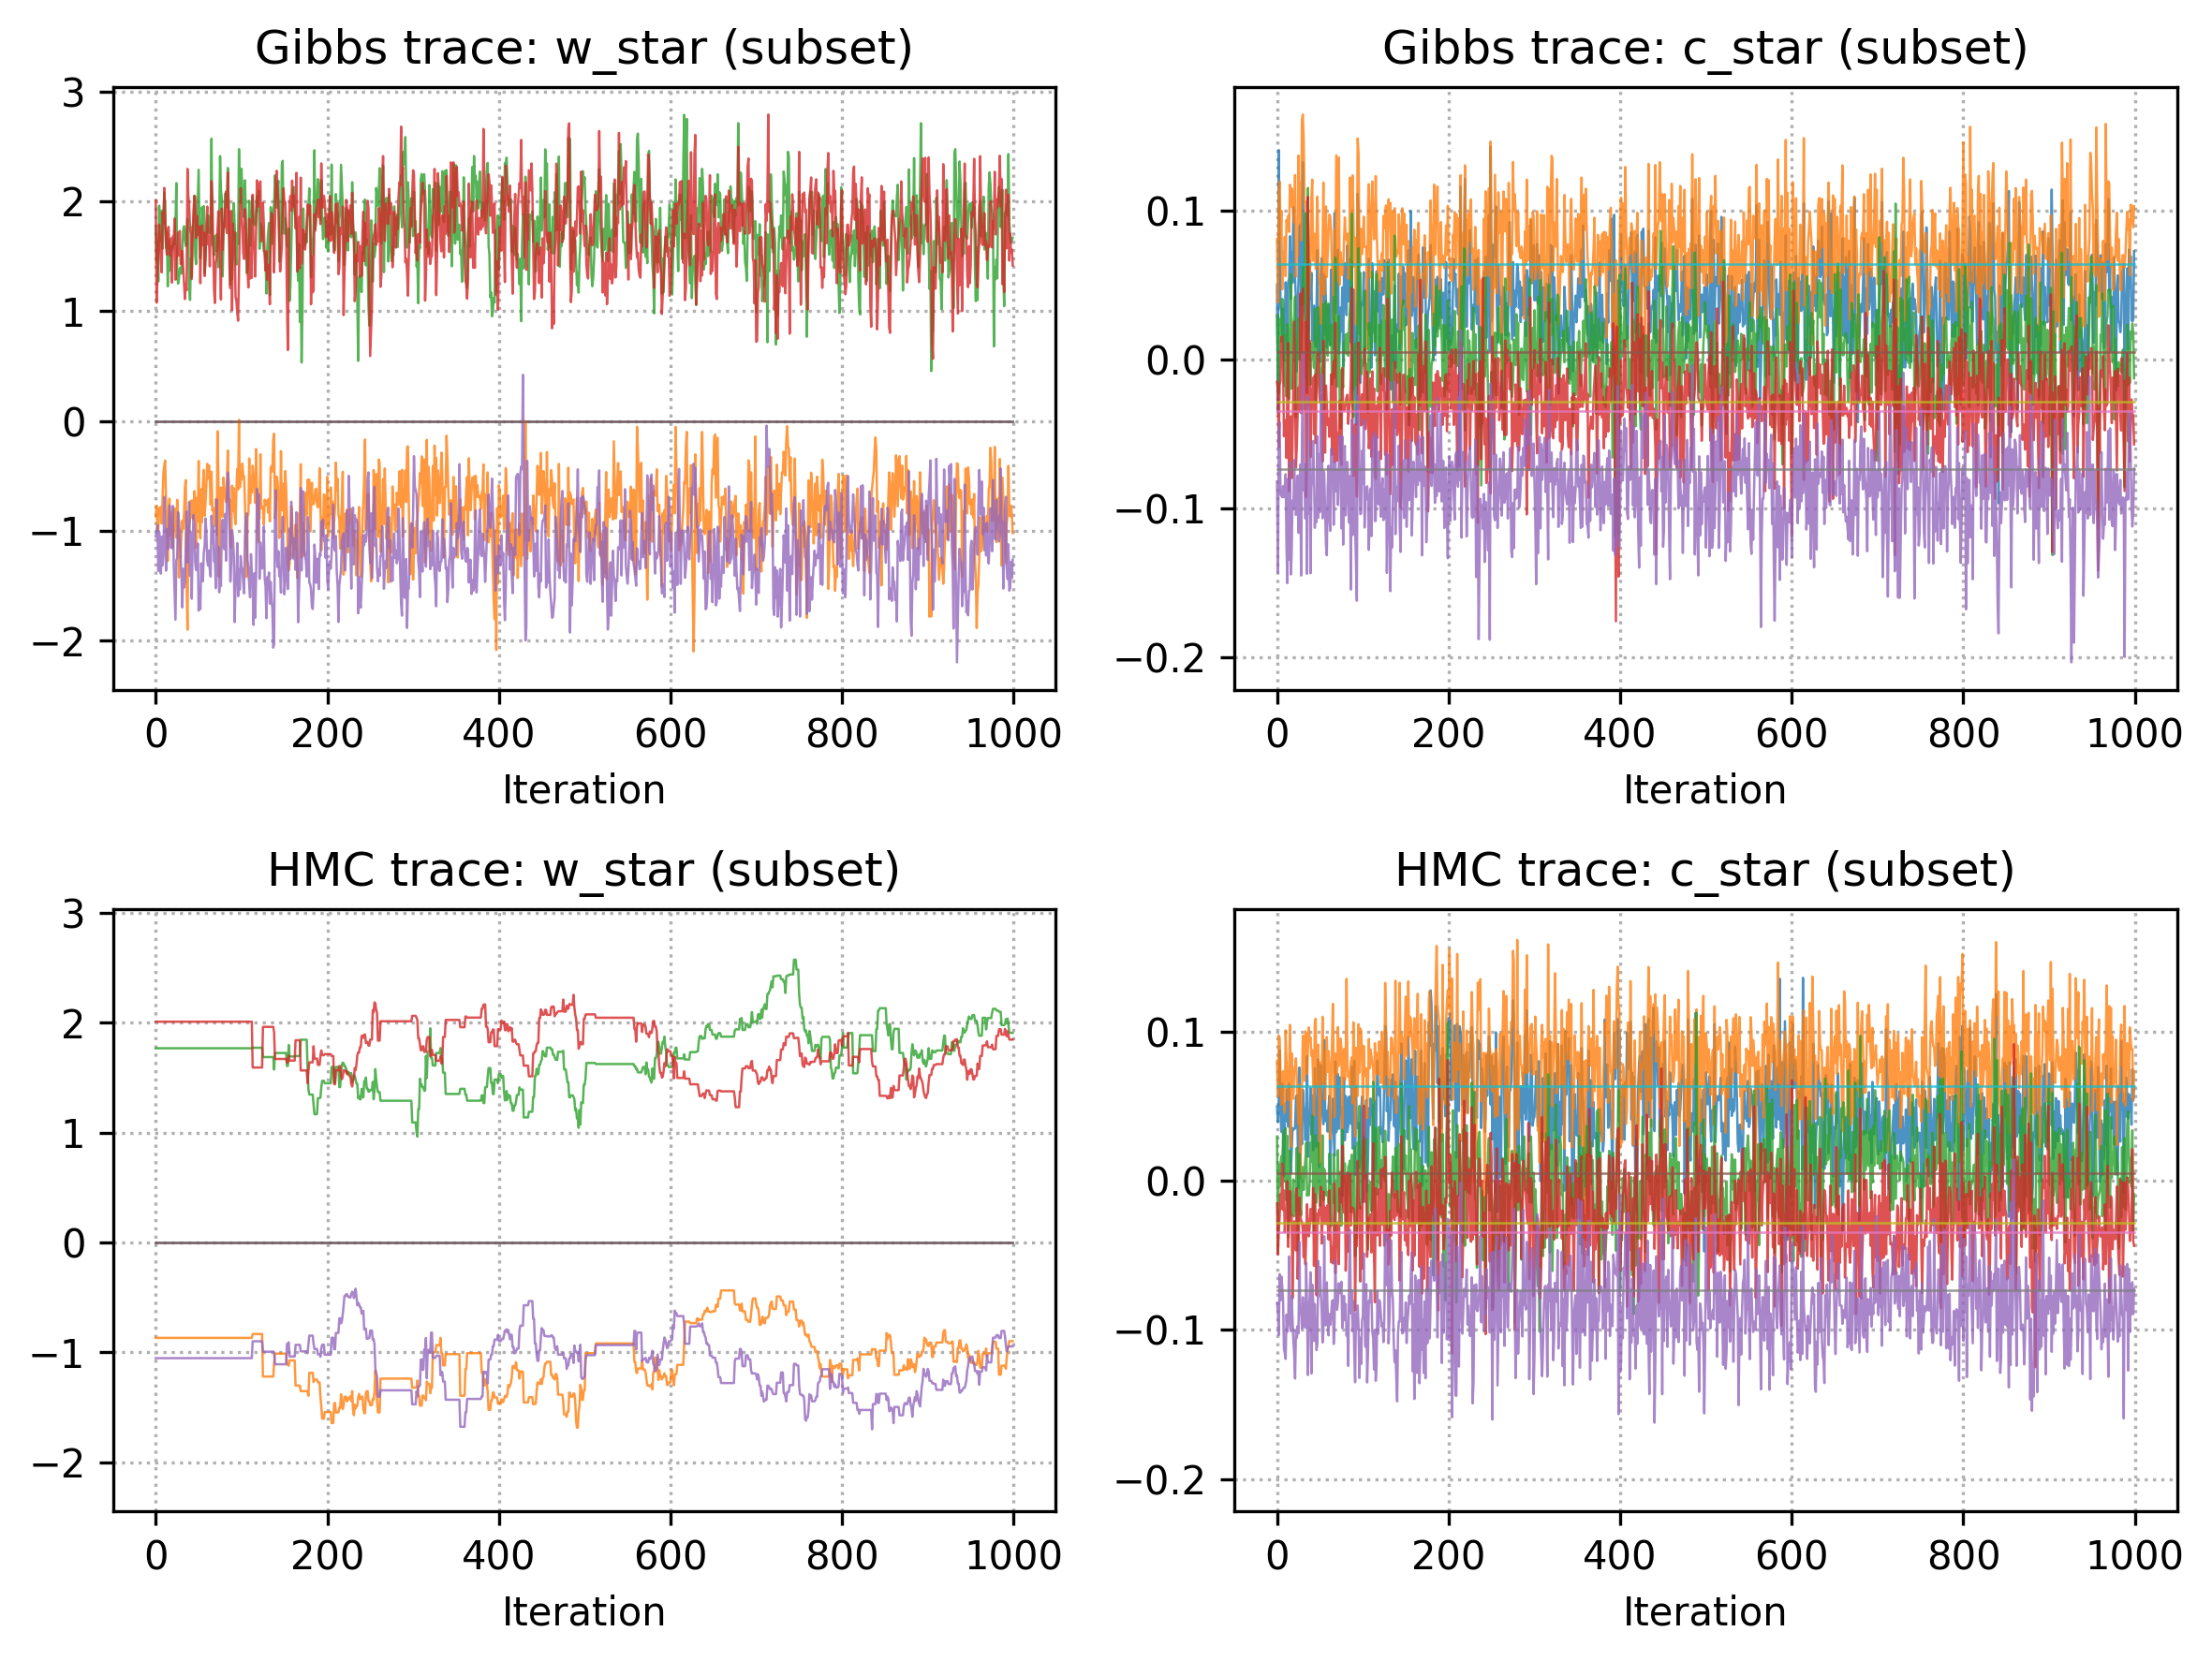

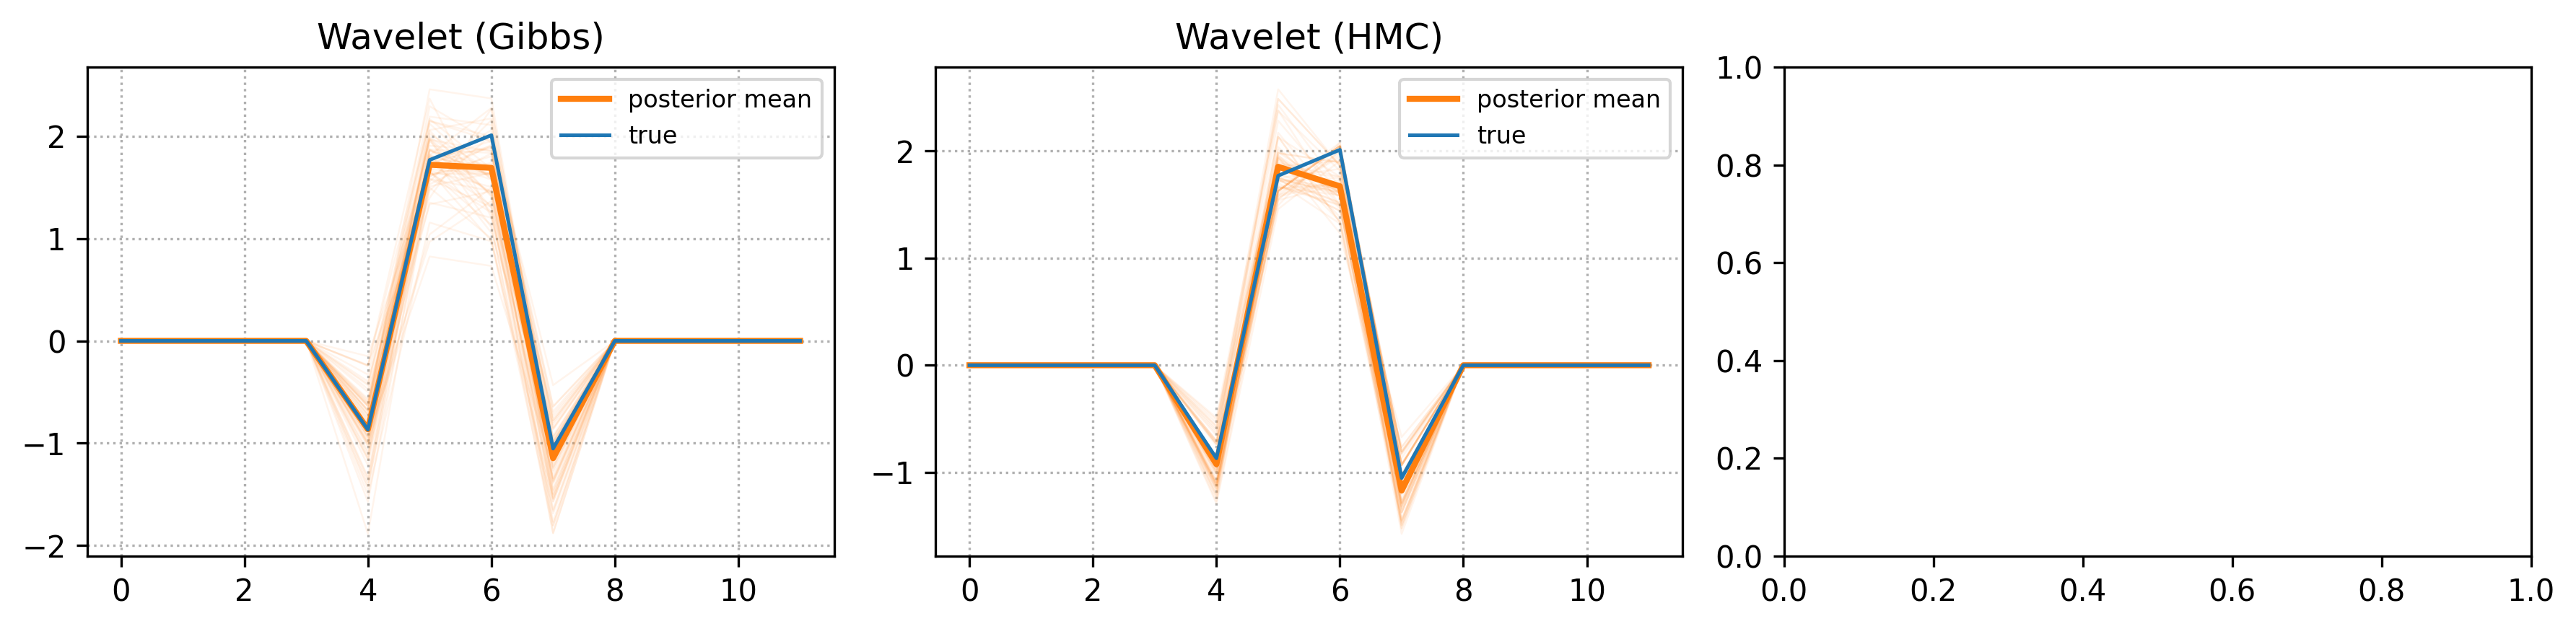

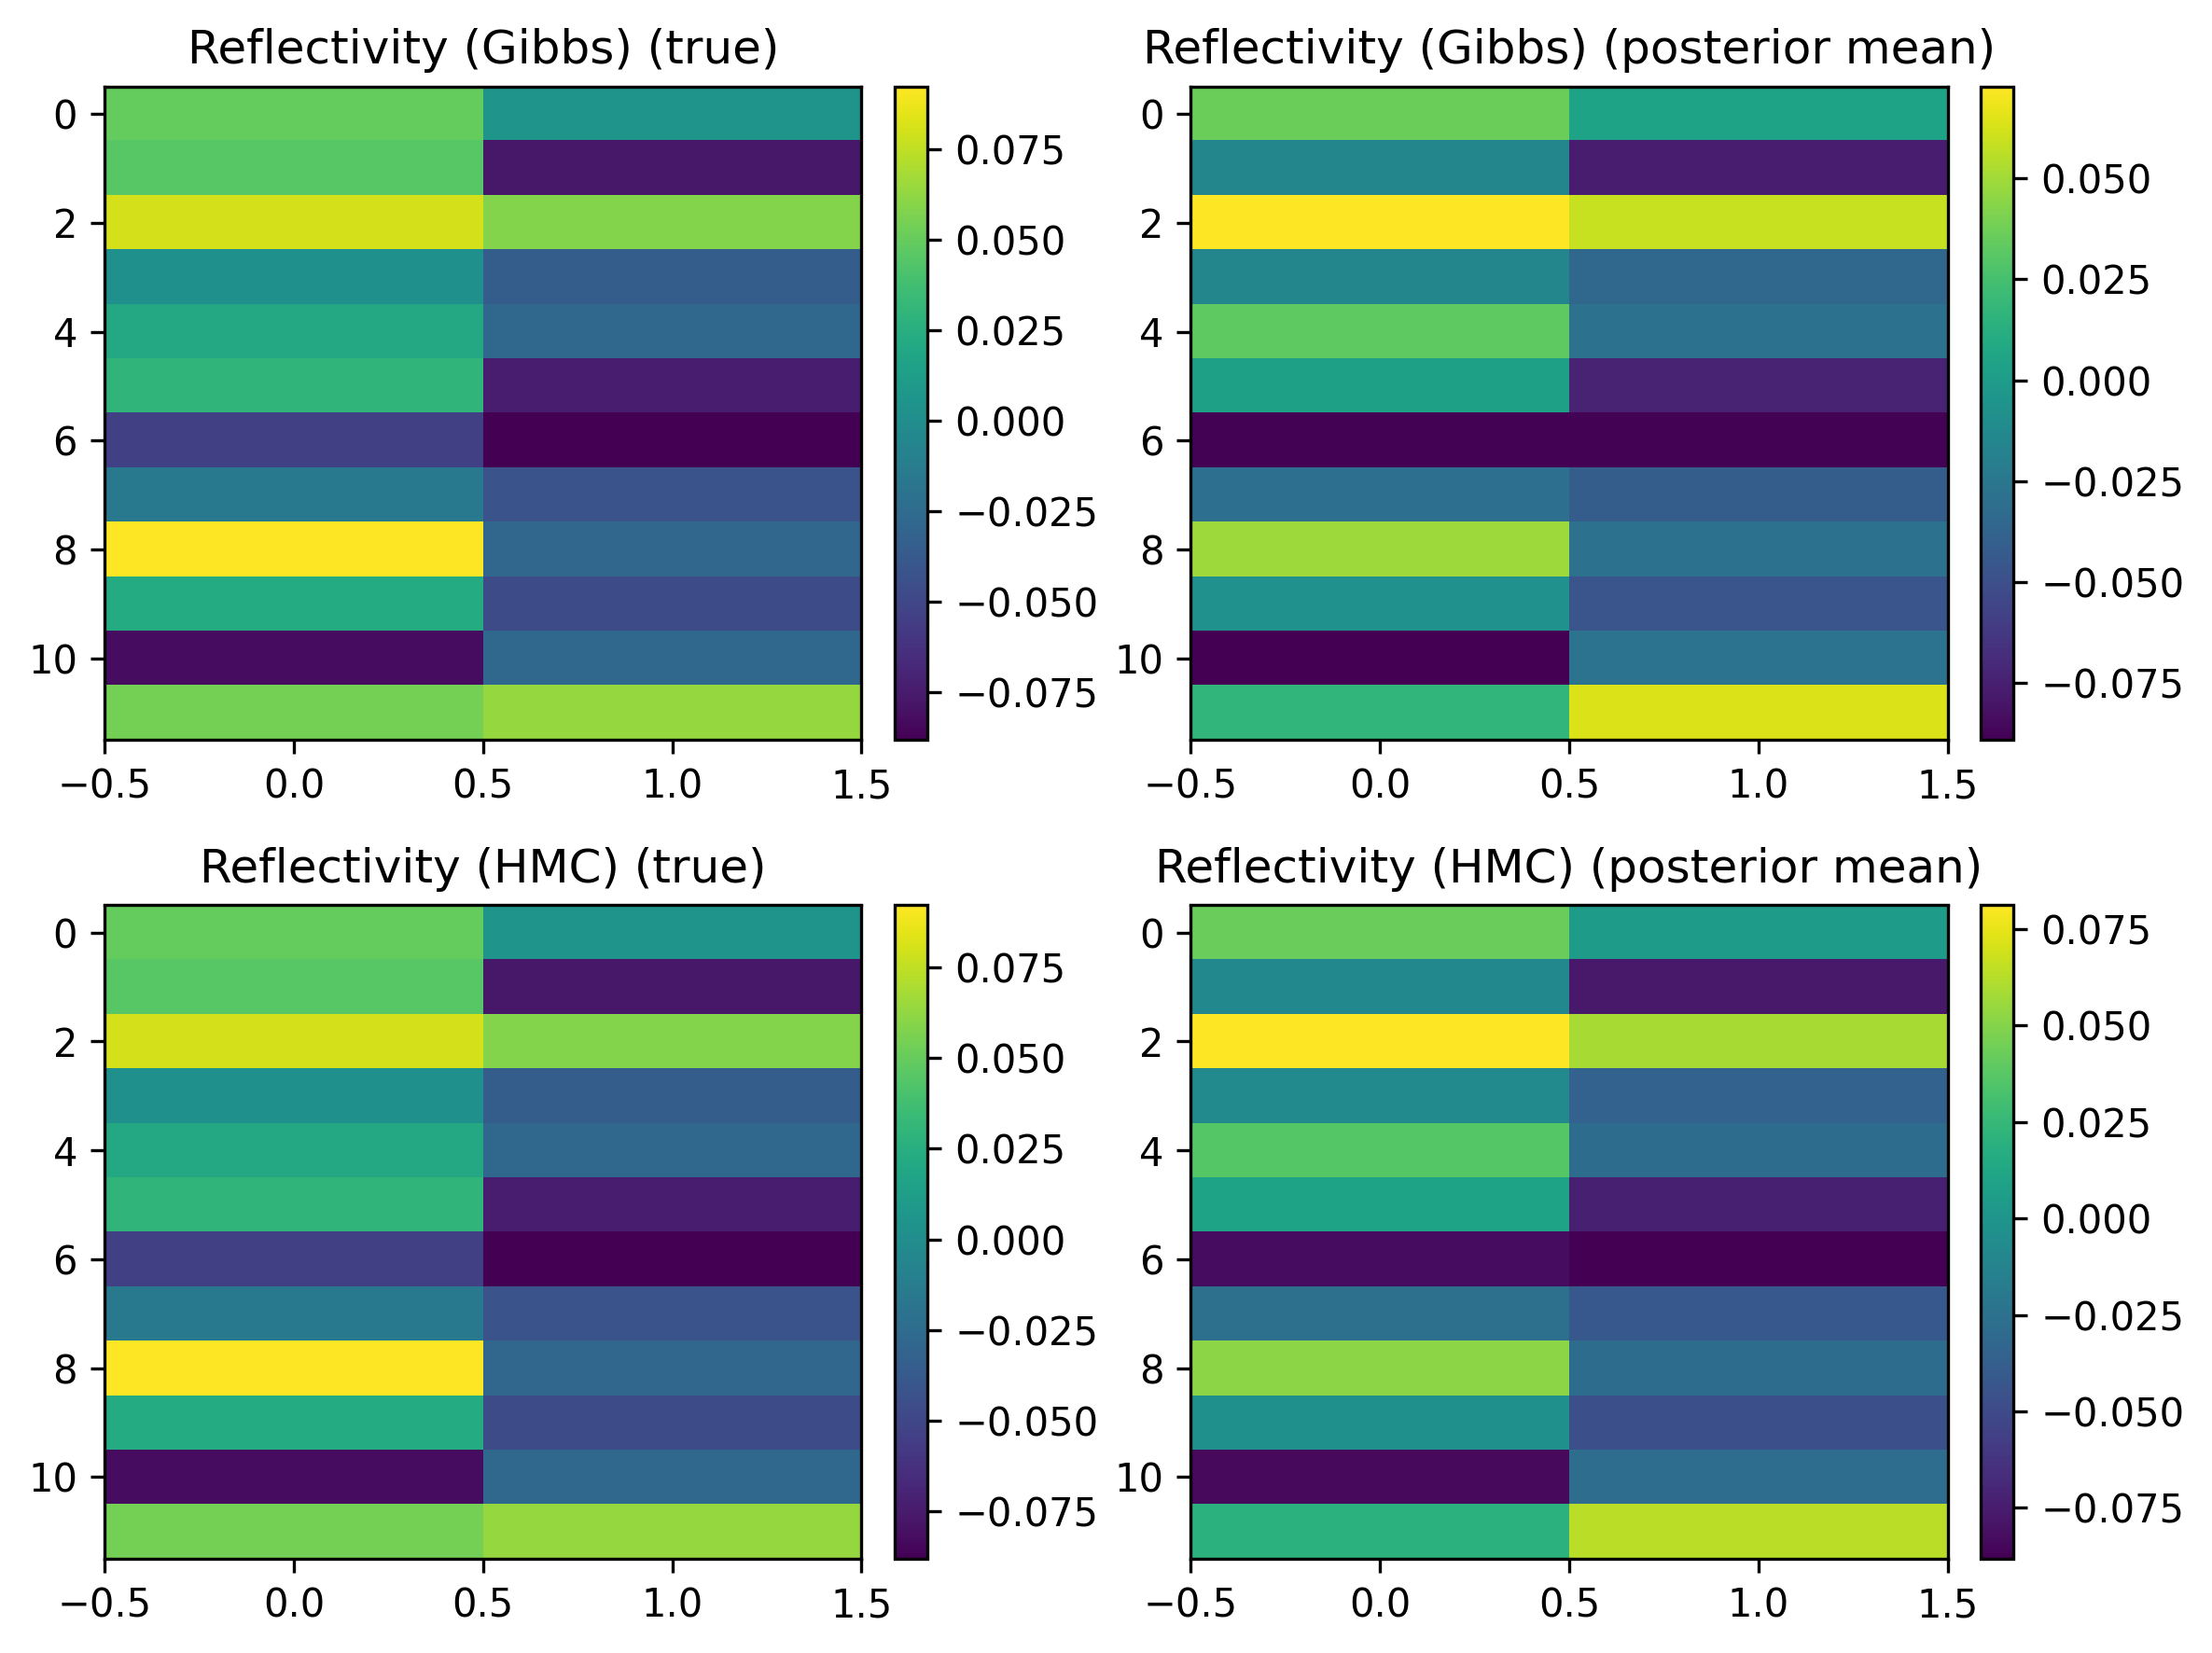

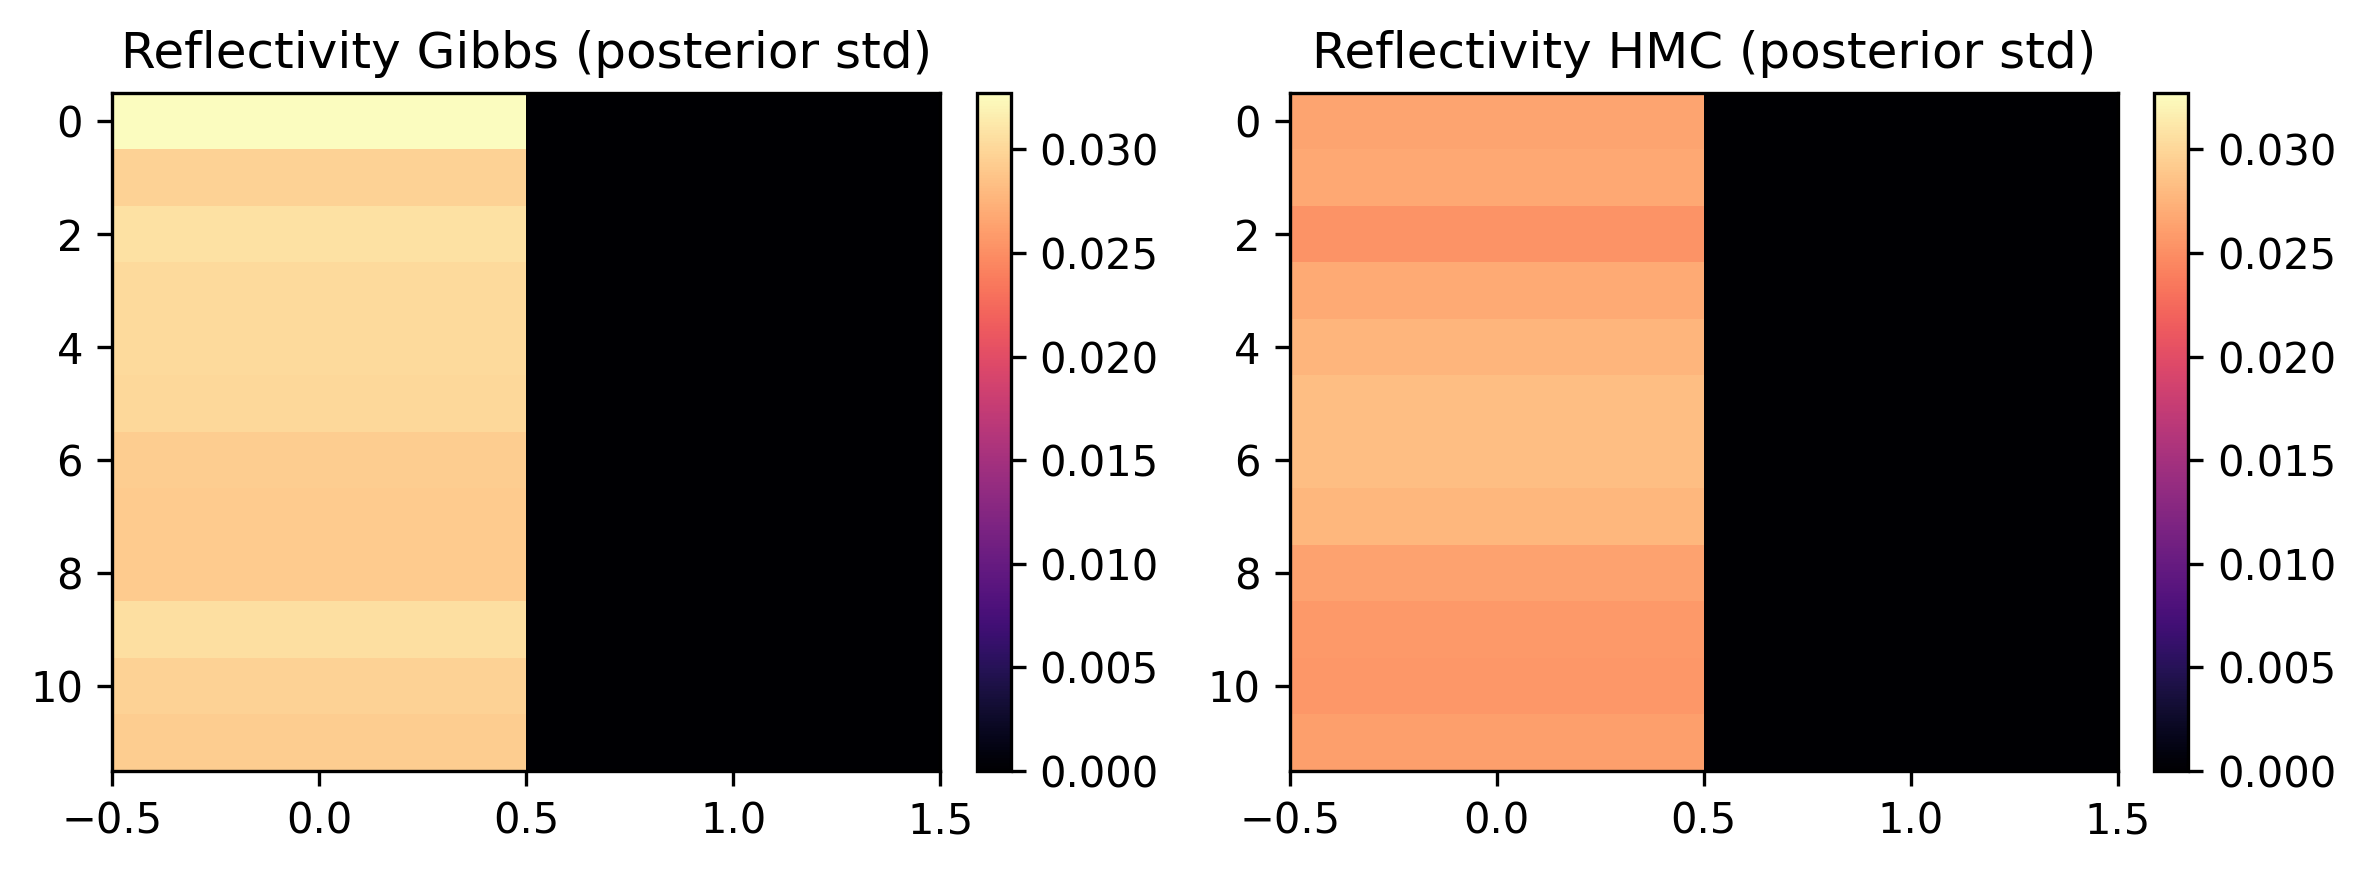

In [ ]:
gibbs_sampler, gibbs_stats, gibbs_est = load_results(gibbs_filenames, thinning=thinning)
hmc_sampler, hmc_stats, hmc_est = load_results(hmc_filenames, thinning=thinning)

# Posterior summaries
gibbs_w_mean, gibbs_w_lo, gibbs_w_hi, gibbs_w_std = posterior_summary(gibbs_est['w_star'], burnin)
gibbs_c_mean, gibbs_c_lo, gibbs_c_hi, gibbs_c_std = posterior_summary(gibbs_est['c_star'], burnin)
gibbs_sigma2w_mean, gibbs_sigma2w_lo, gibbs_sigma2w_hi, _ = posterior_summary(gibbs_est['sigma2w'], burnin)
gibbs_sigma2c_mean, gibbs_sigma2c_lo, gibbs_sigma2c_hi, _ = posterior_summary(gibbs_est['sigma2c'], burnin)
gibbs_zeta_mean, gibbs_zeta_lo, gibbs_zeta_hi, _ = posterior_summary(gibbs_est['zeta'], burnin)

hmc_w_mean, hmc_w_lo, hmc_w_hi, hmc_w_std = posterior_summary(hmc_est['w_star'], burnin)
hmc_c_mean, hmc_c_lo, hmc_c_hi, hmc_c_std = posterior_summary(hmc_est['c_star'], burnin)
hmc_sigma2w_mean, hmc_sigma2w_lo, hmc_sigma2w_hi, _ = posterior_summary(hmc_est['sigma2w'], burnin)
hmc_sigma2c_mean, hmc_sigma2c_lo, hmc_sigma2c_hi, _ = posterior_summary(hmc_est['sigma2c'], burnin)
hmc_zeta_mean, hmc_zeta_lo, hmc_zeta_hi, _ = posterior_summary(hmc_est['zeta'], burnin)

# True scalar values
true_sigma2w = float(np.squeeze(data_true.theta['sigma2w']))
true_sigma2c = float(np.squeeze(data_true.theta['sigma2c']))
true_zeta = float(np.squeeze(data_true.theta['zeta']))

# --- Posterior distributions for scalar parameters ---
fig, axs = plt.subplots(2, 3, figsize=(10, 9), sharex=True, sharey='col')
axs = axs.reshape(-1)
scalar_specs = [
    ('sigma2w', gibbs_est['sigma2w'], gibbs_sigma2w_mean, true_sigma2w, 'Gibbs: sigma2w'),
    ('sigma2c', gibbs_est['sigma2c'], gibbs_sigma2c_mean, true_sigma2c, 'Gibbs: sigma2c'),
    ('zeta', gibbs_est['zeta'], gibbs_zeta_mean, true_zeta, 'Gibbs: zeta'),
    ('sigma2w', hmc_est['sigma2w'], hmc_sigma2w_mean, true_sigma2w, 'HMC: sigma2w'),
    ('sigma2c', hmc_est['sigma2c'], hmc_sigma2c_mean, true_sigma2c, 'HMC: sigma2c'),
    ('zeta', hmc_est['zeta'], hmc_zeta_mean, true_zeta, 'HMC: zeta')
]
for ax, (_, samples, mean_val, true_val, title) in zip(axs, scalar_specs):
    used = samples[:, burnin:] if samples.shape[1] > burnin else samples
    ax.hist(used.flatten(), bins=30, color='0.6', alpha=0.7)
    ax.axvline(float(np.squeeze(mean_val)), color='C1', linewidth=2, label='mean')
    ax.axvline(true_val, color='C0', linewidth=2, linestyle='--', label='true')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle=':')
plt.tight_layout()
scalar_path = os.path.join(figures_dir, f'{folder_id}_posterior_scalars.png')
plt.savefig(scalar_path, dpi=200)
print('Saved:', scalar_path)

# --- Trace plots for all parameters (shared y per sigma) ---
fig, axs = plt.subplots(2, 3, figsize=(10, 9), sharey='col')
plot_trace(gibbs_est['sigma2w'], 'Gibbs trace: sigma2w', axs[0, 0], true_val=true_sigma2w, mean_val=gibbs_sigma2w_mean)
plot_trace(gibbs_est['sigma2c'], 'Gibbs trace: sigma2c', axs[0, 1], true_val=true_sigma2c, mean_val=gibbs_sigma2c_mean)
plot_trace(gibbs_est['zeta'], 'Gibbs trace: zeta', axs[0, 2], true_val=true_zeta, mean_val=gibbs_zeta_mean)
plot_trace(hmc_est['sigma2w'], 'HMC trace: sigma2w', axs[1, 0], true_val=true_sigma2w, mean_val=hmc_sigma2w_mean)
plot_trace(hmc_est['sigma2c'], 'HMC trace: sigma2c', axs[1, 1], true_val=true_sigma2c, mean_val=hmc_sigma2c_mean)
plot_trace(hmc_est['zeta'], 'HMC trace: zeta', axs[1, 2], true_val=true_zeta, mean_val=hmc_zeta_mean)
plt.tight_layout()
trace_scalar_path = os.path.join(figures_dir, f'{folder_id}_trace_scalars.png')
plt.savefig(trace_scalar_path, dpi=200)
print('Saved:', trace_scalar_path)

fig, axs = plt.subplots(2, 2, figsize=(8, 6), sharey='col')
plot_trace_subset(gibbs_est['w_star'], 'Gibbs trace: w_star (subset)', axs[0, 0], n_traces=6, central_k=eff_blur_length)
plot_trace_subset(hmc_est['w_star'], 'HMC trace: w_star (subset)', axs[1, 0], n_traces=6, central_k=eff_blur_length)
plot_trace_subset(gibbs_est['c_star'], 'Gibbs trace: c_star (subset)', axs[0, 1], n_traces=10)
plot_trace_subset(hmc_est['c_star'], 'HMC trace: c_star (subset)', axs[1, 1], n_traces=10)
plt.tight_layout()
trace_field_path = os.path.join(figures_dir, f'{folder_id}_trace_fields.png')
plt.savefig(trace_field_path, dpi=200)
print('Saved:', trace_field_path)

# --- Blur posterior (draws + mean) ---
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
plot_vector_posterior_draws(data_true.theta['w_star'], gibbs_est['w_star'], burnin_idx=burnin, n_draws=60, title='Blur (Gibbs)', ax=axs[0])
plot_vector_posterior_draws(data_true.theta['w_star'], hmc_est['w_star'], burnin_idx=burnin, n_draws=60, title='Blur (HMC)', ax=axs[1])
plt.tight_layout()
blur_path = os.path.join(figures_dir, f'{folder_id}_wavelet_posterior.png')
plt.savefig(blur_path, dpi=200)
print('Saved:', blur_path)

# --- Image posterior mean ---
fig, axs = plt.subplots(2, 2, figsize=(8, 6))
plot_field_mean(data_true.theta['c_star'], gibbs_c_mean, lattice, 'Image (Gibbs)', axs[0, 0], axs[0, 1])
plot_field_mean(data_true.theta['c_star'], hmc_c_mean, lattice, 'Image (HMC)', axs[1, 0], axs[1, 1])
plt.tight_layout()
c_mean_path = os.path.join(figures_dir, f'{folder_id}_reflectivity_mean.png')
plt.savefig(c_mean_path, dpi=200)
print('Saved:', c_mean_path)

# --- Image posterior std ---
std_vals = np.concatenate([
    gibbs_c_std.reshape(-1),
    hmc_c_std.reshape(-1),
])
c_std_vmin = float(np.min(std_vals))
c_std_vmax = float(np.max(std_vals))

fig, axs = plt.subplots(1, 2, figsize=(8, 3))
plot_field_std(gibbs_c_std, lattice, 'Image Gibbs', axs[0], vmin=c_std_vmin, vmax=c_std_vmax)
plot_field_std(hmc_c_std, lattice, 'Image HMC', axs[1], vmin=c_std_vmin, vmax=c_std_vmax)
plt.tight_layout()
c_std_path = os.path.join(figures_dir, f'{folder_id}_reflectivity_std.png')
plt.savefig(c_std_path, dpi=200)
print('Saved:', c_std_path)

# --- Summary table ---
table = [
    {
        'algorithm': 'gibbs',
        'rmse_w': rmse(data_true.theta['w_star'].reshape(-1), gibbs_w_mean.reshape(-1)),
        'rmse_c': rmse(data_true.theta['c_star'].reshape(-1), gibbs_c_mean.reshape(-1)),
        'sigma2w_mean': float(np.squeeze(gibbs_sigma2w_mean)),
        'sigma2c_mean': float(np.squeeze(gibbs_sigma2c_mean)),
        'zeta_mean': float(np.squeeze(gibbs_zeta_mean)),
    },
    {
        'algorithm': 'collapsed_hmc',
        'rmse_w': rmse(data_true.theta['w_star'].reshape(-1), hmc_w_mean.reshape(-1)),
        'rmse_c': rmse(data_true.theta['c_star'].reshape(-1), hmc_c_mean.reshape(-1)),
        'sigma2w_mean': float(np.squeeze(hmc_sigma2w_mean)),
        'sigma2c_mean': float(np.squeeze(hmc_sigma2c_mean)),
        'zeta_mean': float(np.squeeze(hmc_zeta_mean)),
    }
]

df_summary = pd.DataFrame(table)
summary_path = os.path.join(tables_dir, f'{folder_id}_summary.csv')
df_summary.to_csv(summary_path, index=False)
print('Saved:', summary_path)
df_summary
